In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from tensorflow.keras.datasets import fashion_mnist

In [3]:
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
train_images.ndim

3

In [5]:
train_labels.ndim

1

In [6]:
train_images.shape

(60000, 28, 28)

In [7]:
train_labels

array([9, 0, 0, ..., 3, 0, 5], dtype=uint8)

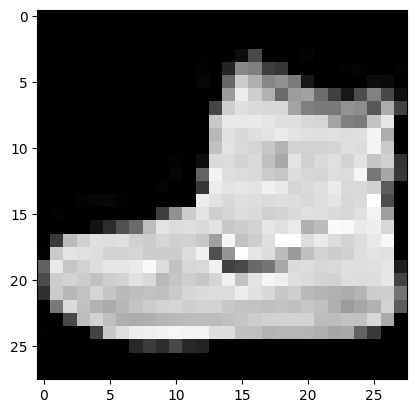

In [8]:
plt.imshow(train_images[0], cmap='gray')

In [9]:
train_labels[0]

np.uint8(9)

In [10]:
class_names = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]

In [11]:
print(class_names[train_labels[0]])

Ankle boot


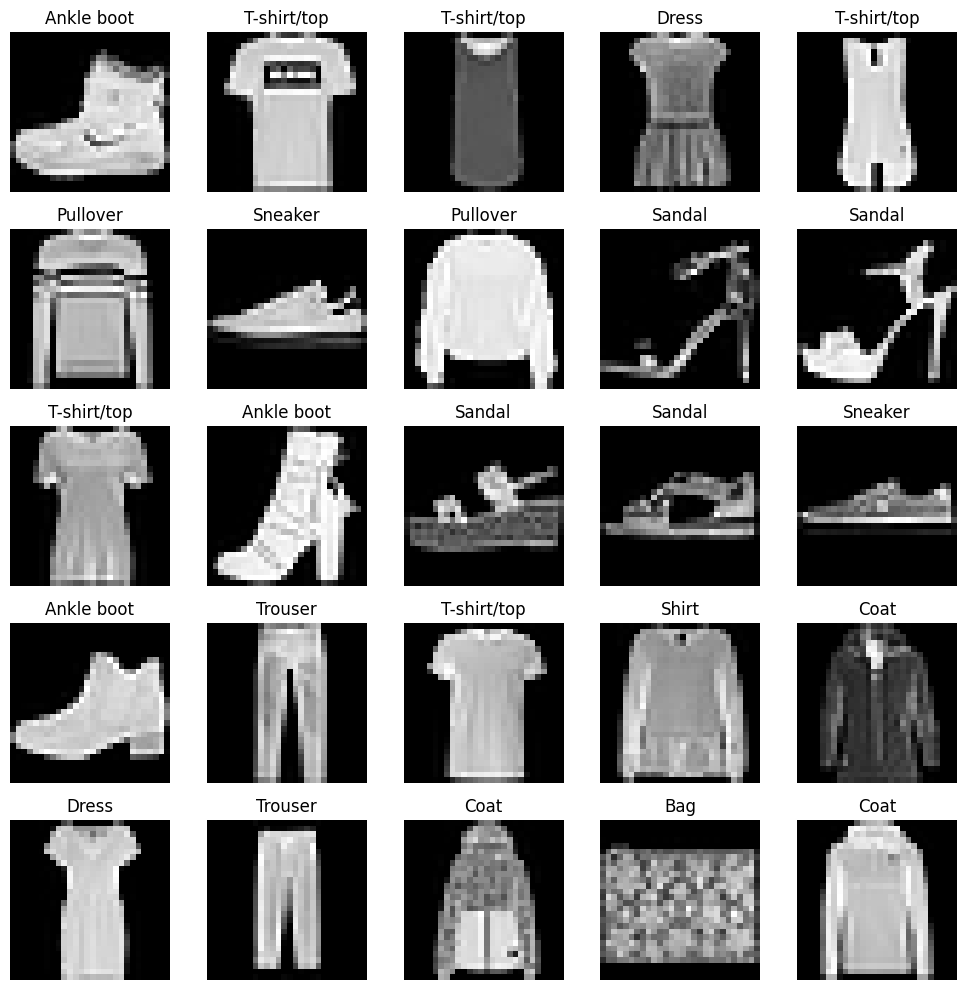

In [12]:
plt.figure(figsize=(10,10))
for i in range(25):
  plt.subplot(5,5,i+1)
  plt.imshow(train_images[i], cmap='gray')
  plt.title(class_names[train_labels[i]])
  plt.axis('off')
plt.tight_layout()
plt.show()

In [13]:
print(train_images[0])
print(train_images[0].min())
print(train_images[0].max())



[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   1   0   0  13  73   0
    0   1   4   0   0   0   0   1   1   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3   0  36 136 127  62
   54   0   0   0   1   3   4   0   0   3]
 [  0   0   0   0   0   0   0   0   0   0   0   0   6   0 102 204 176 134
  144 123  23   0   0   0   0  12  10   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0 155 236 207 178
  107 156 161 109  64  23  77 130  72  15]
 [  0   0   0   0   0   0   0   0   0   0   0   1   0  69 207 223 218 216
  216 163 127 121 122 146 141  88 172  66]
 [  0   0   0   0   0   0   0   0   0   1   1   1   0 200 232 23

In [14]:
from tensorflow.keras.utils import to_categorical
encoded_train_labels = to_categorical(train_labels)
encoded_test_labels = to_categorical(test_labels)
print(encoded_train_labels.shape)
print(encoded_test_labels.shape)

(60000, 10)
(10000, 10)


In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [16]:
model = Sequential([
    Dense(512, activation='relu', input_shape=(784,)),
    Dense(10, activation='softmax')
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 407,050 (1.55 MB)

 Trainable params: 407,050 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
model.compile(
    optimizer= 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

In [19]:
print(train_images.shape)
print(test_images.shape)

(60000, 28, 28)
(10000, 28, 28)


In [20]:
train_images = train_images.reshape((60000, 784))
test_images = test_images.reshape((10000, 784))

In [21]:
print(train_images.shape)
test_images.shape

(60000, 784)


(10000, 784)

In [22]:
train_images = train_images.astype('float32')
test_images = test_images.astype('float32')

In [23]:
train_images = train_images / 255
test_images = test_images / 255

In [24]:
# history = model.fit(

#           train_images,
#           train_labels,
#           epochs = 20,
#           batch_size = 128,
#           validation_split = 0.1

# )
history = model.fit(

    train_images,
    train_labels,
    epochs=20,
    batch_size=128,
    validation_split=0.1
)


Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8205 - loss: 0.5163 - val_accuracy: 0.8597 - val_loss: 0.3992
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8649 - loss: 0.3800 - val_accuracy: 0.8585 - val_loss: 0.3938
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8779 - loss: 0.3369 - val_accuracy: 0.8683 - val_loss: 0.3588
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8862 - loss: 0.3112 - val_accuracy: 0.8708 - val_loss: 0.3641
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.8935 - loss: 0.2904 - val_accuracy: 0.8807 - val_loss: 0.3391
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8989 - loss: 0.2733 - val_accuracy: 0.8810 - val_loss: 0.3250
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9052 - loss: 0.2608 - val_accuracy: 0.8892 - val_loss: 0.3103
Epoch 8/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9091 - loss: 0.2481 - val_accu

In [25]:
print(train_images.shape)
print(train_labels.shape)

print(train_images.min())
print(train_images.max())

print(type(train_images))
print(type(train_labels))

(60000, 784)
(60000,)
0.0
1.0
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [26]:
test_loss, test_accuracy = model.evaluate(
    test_images,
    test_labels,
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8913 - loss: 0.3263


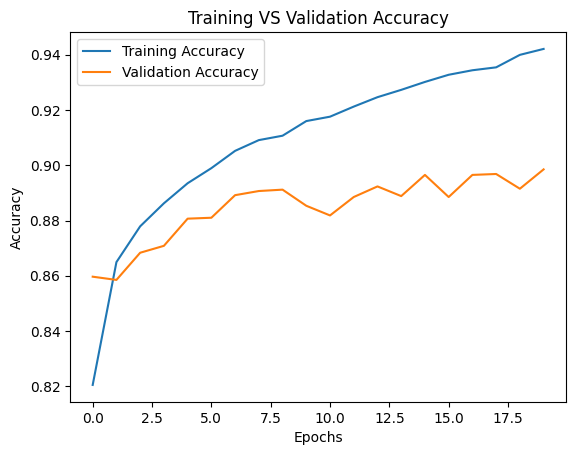

In [27]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Training VS Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(["Training Accuracy", "Validation Accuracy"])
plt.show()

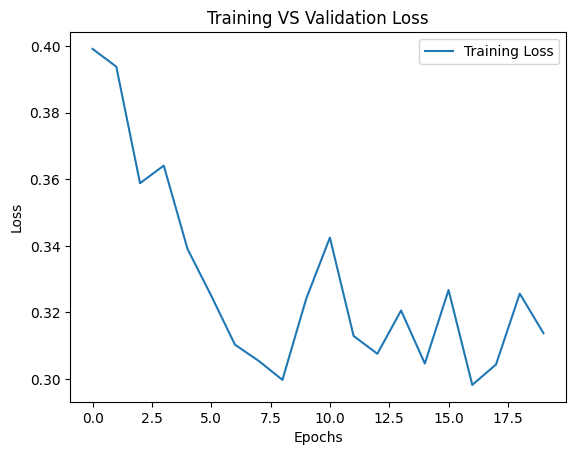

In [28]:
plt.plot(history.history['val_loss'])
plt.title('Training VS Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Training Loss', 'Validation Loss'])
plt.show()

In [29]:
predictions = model.predict(test_images)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [30]:
predicted_labels = np.argmax(predictions, axis=1)

In [31]:
# print('Predicted Label':, predicted_labels[0])
print("Predicted Label:", predicted_labels[0])
print('Predicted Class:', class_names[predicted_labels[0]])
print('Actual Label:', test_labels[0])
print('Actual Class:', class_names[test_labels[0]])


Predicted Label: 9
Predicted Class: Ankle boot
Actual Label: 9
Actual Class: Ankle boot


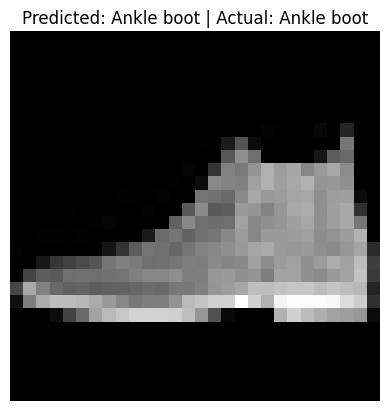

In [32]:
plt.imshow(test_images[0].reshape(28,28), cmap='gray')
# plt.title('Pedicted:'+ class_names[predicted_labels[0]] + '| Actual:'+class_names[test_images[0]])
plt.title(
    "Predicted: " + class_names[predicted_labels[0]] +
    " | Actual: " + class_names[test_labels[0]]
)
plt.axis('off')
plt.show()

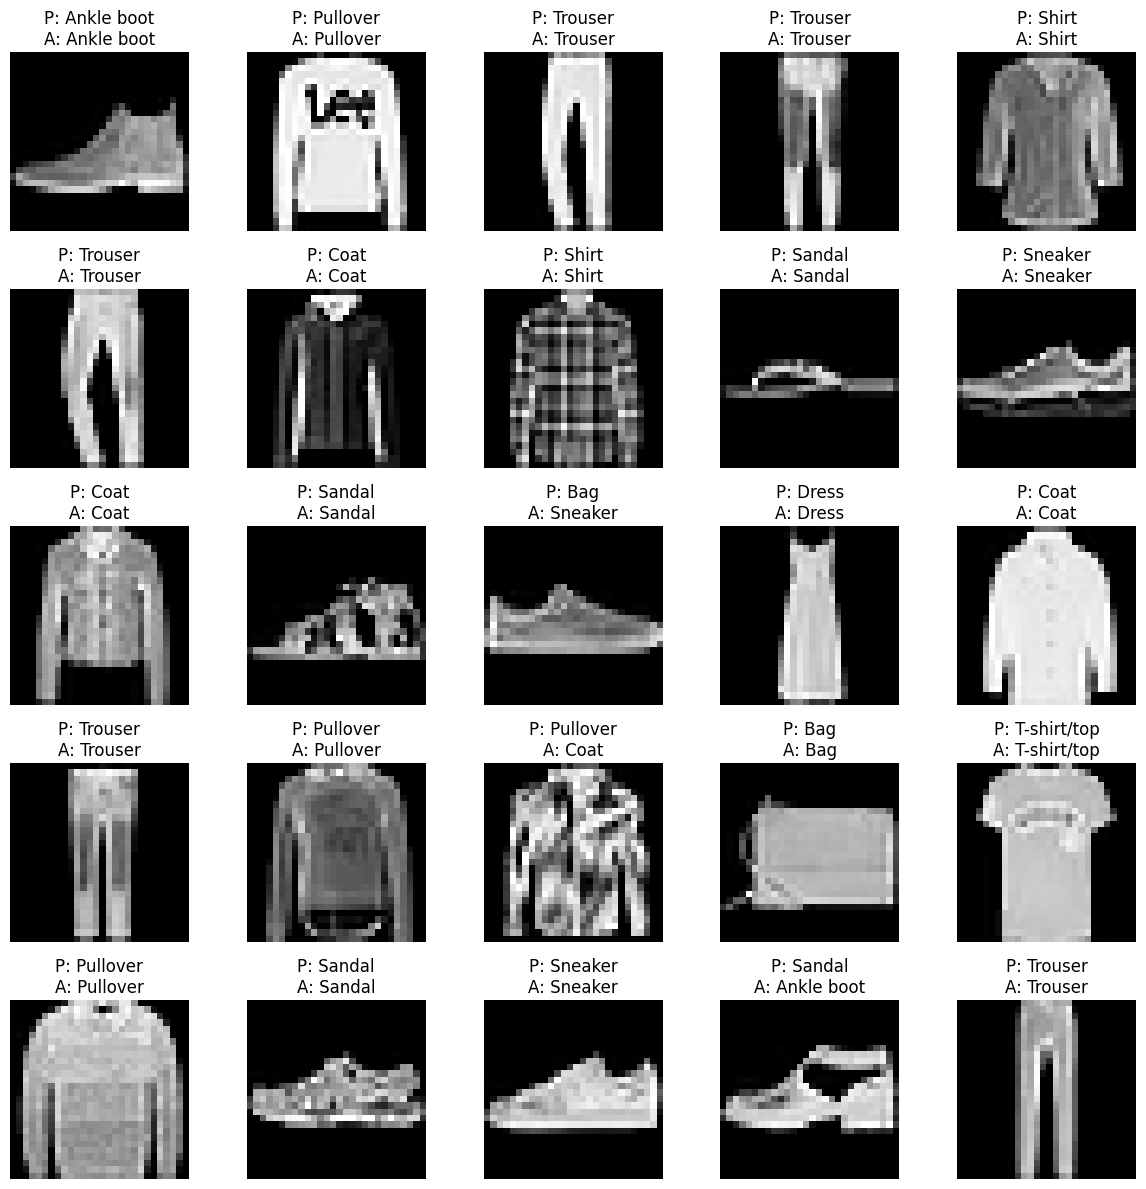

In [33]:
plt.figure(figsize=(12,12))
for i in range(25):
  plt.subplot(5,5,i+1)
  plt.imshow(test_images[i].reshape(28,28), cmap='gray')
  plt.title("P: " + class_names[predicted_labels[i]] +
        "\nA: " + class_names[test_labels[i]])
  plt.axis('off')
plt.tight_layout()
plt.show()

In [34]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(test_labels, predicted_labels)
print(cm)

[[807   2  14  23   4   2 138   0  10   0]
 [  1 980   2  10   3   0   2   0   2   0]
 [  8   0 807  14  86   0  82   0   3   0]
 [ 23   5   6 915  23   0  22   0   6   0]
 [  1   1  82  37 788   0  88   0   3   0]
 [  0   0   0   0   0 966   0  21   1  12]
 [103   0  65  28  48   0 745   0  11   0]
 [  0   0   0   0   0  12   0 970   1  17]
 [  3   0   2   4   2   3   5   3 978   0]
 [  0   0   0   0   0   8   1  34   0 957]]


In [37]:
sample_index = 10
sample_image = test_images[sample_index]
sample_prediction = model.predict(
    np.expand_dims(sample_image, axis=0)
)

sample_label = np.argmax(sample_prediction)
print("Predicted:", class_names[sample_label])
print("Actual:", class_names[test_labels[sample_index]])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
Predicted: Coat
Actual: Coat


In [39]:
from tensorflow.keras.preprocessing import image

t_shirt_img = image.load_img(
    "t-shirt.jpg",
    color_mode="grayscale",
    target_size=(28, 28)
)

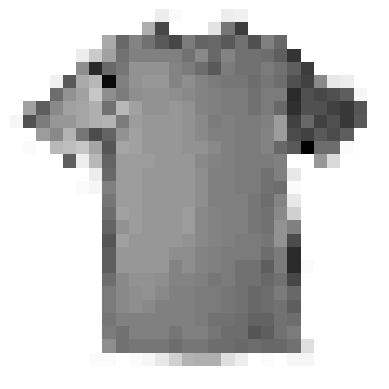

In [40]:
plt.imshow(t_shirt_img, cmap="gray")
plt.axis("off")
plt.show()

In [41]:
t_shirt_img_array = image.img_to_array(t_shirt_img)
t_shirt_img_array = t_shirt_img_array.reshape(1, 784)
t_shirt_img_array = t_shirt_img_array.astype("float32")
t_shirt_img_array = t_shirt_img_array / 255.0

In [42]:
prediction = model.predict(t_shirt_img_array)
predicted_label = np.argmax(prediction, axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step


In [43]:
print("Predicted:", class_names[predicted_label[0]])

Predicted: Bag


In [44]:
print(prediction)
print(predicted_label)

[[4.6863682e-24 2.3542180e-23 1.7096244e-08 5.6178366e-26 4.4566527e-19
  2.3452371e-30 1.1889850e-14 2.7969544e-28 1.0000000e+00 2.8587558e-26]]
[8]


In [45]:
bag_image = image.load_img(
    "bag.jpg",
    color_mode="grayscale",
    target_size=(28, 28)
)

In [46]:
bag_array = image.img_to_array(bag_image)
bag_array = bag_array.reshape(1, 784)
bag_array = bag_array.astype("float32")
bag_array = bag_array / 255.0

In [47]:
bag_prediction = model.predict(bag_array)
bag_predicted_label = np.argmax(bag_prediction, axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


In [48]:
print("Bag Prediction:", class_names[bag_predicted_label[0]])

Bag Prediction: Bag


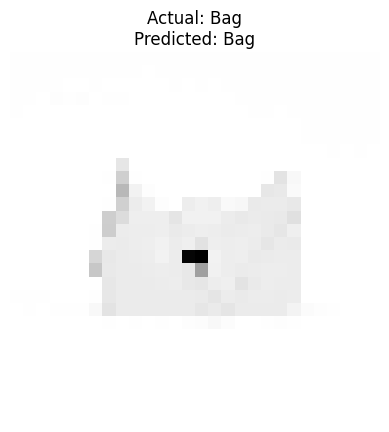

In [49]:
plt.imshow(bag_image, cmap="gray")
plt.title(
    "Actual: Bag\n"
    "Predicted: " + class_names[bag_predicted_label[0]]
)
plt.axis("off")
plt.show()

In [50]:
sneaker_image = image.load_img(
    "sneaker.jpg",
    color_mode="grayscale",
    target_size=(28, 28)
)

In [51]:
sneaker_array = image.img_to_array(sneaker_image)
sneaker_array = sneaker_array.reshape(1, 784)
sneaker_array = sneaker_array.astype("float32")
sneaker_array = sneaker_array / 255.0


In [52]:
sneaker_prediction = model.predict(sneaker_array)
sneaker_predicted_label = np.argmax(sneaker_prediction, axis=1)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


In [53]:

print("Sneaker Prediction:", class_names[sneaker_predicted_label[0]])

Sneaker Prediction: Bag


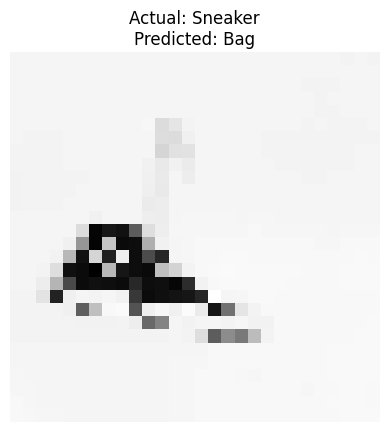

In [54]:
plt.imshow(sneaker_image, cmap="gray")
plt.title(
    "Actual: Sneaker\n"
    "Predicted: " + class_names[sneaker_predicted_label[0]]
)
plt.axis("off")
plt.show()

In [55]:
for i in range(10):
    print(class_names[i], sneaker_prediction[0][i])

T-shirt/top 2.4923045e-21
Trouser 1.2974584e-19
Pullover 9.95296e-07
Dress 1.295527e-23
Coat 1.0640702e-17
Sandal 2.9863942e-28
Shirt 1.4831214e-11
Sneaker 1.996731e-24
Bag 0.99999905
Ankle boot 4.238647e-21
